# Assignment 7

## Submit your .ipynb file to Gradescope by Thursday, October 30th **by 10pm**

##### Import the familiar libraries ``pandas``, ``numpy`` and ``matplotlib.pyplot``

##### In addition, we'll import a sublibrary from the ``statsmodels`` library. We'll use this in problems 4 and 5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


##### Run the code chunk below to read the CSV file named `results.csv` in the `data` folder and print the first 5 rows of the dataset (using a quick alternative to `.iloc[:5,:]`). Browse the dataset.

In [3]:
df_results = pd.read_csv("data/results.csv")
df_results.head(10)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
5,6,18,6,3,8,13,6,6,6,3.0,57,\N,\N,50,14,1:29.639,212.974,11
6,7,18,7,5,14,17,7,7,7,2.0,55,\N,\N,22,12,1:29.534,213.224,5
7,8,18,8,6,1,15,8,8,8,1.0,53,\N,\N,20,4,1:27.903,217.180,5
8,9,18,9,2,4,2,\N,R,9,0.0,47,\N,\N,15,9,1:28.753,215.100,4
9,10,18,10,7,12,18,\N,R,10,0.0,43,\N,\N,23,13,1:29.558,213.166,3


### (1)  Check Column Types and Data Cleaning

- Use the attributes ``.dtypes`` to get the data types for each column of the DataFrame. Assign this to a variable named ``results_data_types``.
- The 'milliseconds' column contains string values that should be numeric. Do the following:
    - Replace all non-numeric values in the milliseconds column with ``np.nan``
    - Add a new column to ``df_results`` called 'race_time_ms' by converting the 'milliseconds' column to a numeric data type using ``.to_numeric``

In [5]:
features = pd.read_csv("data/features.csv")
dtypes_before = features.dtypes.astype(str)

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration"]
for col in numeric_cols:
    features[col] = pd.to_numeric(features[col], errors="coerce")


na_counts = features[numeric_cols].isna().sum()

# Clean subset for regression
clean_for_reg = features.dropna(subset=["mpg", "weight"])
dtypes_after = clean_for_reg.dtypes.astype(str)

print("Dtypes before:")
print(dtypes_before)
print("\nDtypes after (cleaned subset):")
print(dtypes_after)
print("\nNA counts after coercion (numeric cols):")
print(na_counts)


Dtypes before:
mpg             float64
cylinders         int64
displacement      int64
horsepower       object
weight            int64
acceleration    float64
vehicle_id       object
dtype: object

Dtypes after (cleaned subset):
mpg             float64
cylinders         int64
displacement      int64
horsepower      float64
weight            int64
acceleration    float64
vehicle_id       object
dtype: object

NA counts after coercion (numeric cols):
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
dtype: int64


### (2) Recoding: Create categorical variables

- The DataFrame has a column called 'position' which records whether a driver finished 1st, 2nd, 3rd, etc.
- Create a new column called 'finish_category' that categorizes the race finish positions as follows:
    - Positions 1-3: 'Podium'
    - Positions 4-10: 'Points'
    - Positions 11-20: 'Midfield'
    - Positions >20: 'Backmarker'

**Hint**: The shortest way to do this is to clean the data in the column and then use the ``.cut`` function in the ``pandas`` library. But this is not the only way to do it.

In [6]:
x = clean_for_reg["weight"].values
y = clean_for_reg["mpg"].values
a, b = np.polyfit(x, y, deg=1)

predicted_mpg = a * clean_for_reg["weight"] + b

print(f"slope a = {a}")
print(f"intercept b = {b}")
print("\nSample of actual vs predicted:")
print(pd.DataFrame({
    "weight": clean_for_reg["weight"],
    "mpg": clean_for_reg["mpg"],
    "predicted_mpg": predicted_mpg
}).head(15))


slope a = -0.0076766100639264895
intercept b = 46.317364420265676

Sample of actual vs predicted:
    weight   mpg  predicted_mpg
0     3504  18.0      19.418523
1     3693  15.0      17.967643
2     3436  18.0      19.940532
3     3433  16.0      19.963562
4     3449  17.0      19.840736
5     4341  15.0      12.993200
6     4354  14.0      12.893404
7     4312  14.0      13.215822
8     4425  14.0      12.348365
9     3850  15.0      16.762416
10    3563  15.0      18.965603
11    3609  14.0      18.612479
12    3761  15.0      17.445634
13    3086  14.0      22.627346
14    2372  24.0      28.108445


### (3) Calculate Race Duration
- Create a new column called 'race_duration_minutes' where we convert the race time in milliseconds to minutes by dividing each millisecond value by 60,000 (which equals $6 \times 10^4$). Equivalently, you can multiply each millisecond value by $6 \times 10^{-4}$

- Each F1 car is associated with a "constructor", the entity which designs the chassis and engine of the car. Use ``.groupby`` to create a DataFrameGroupBy object, grouping by the "constructorID" column.

- Compute the average race duration in minutes for each constructor. Then print out the constructorId's with the 5 fastest average times. (Both the constructorId and the corresponding average time in minutes should be visible)

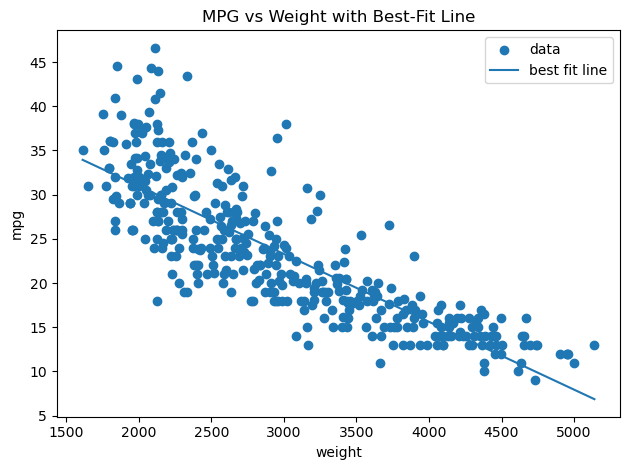

In [7]:

order = np.argsort(clean_for_reg["weight"].values)

plt.figure()
plt.scatter(clean_for_reg["weight"], clean_for_reg["mpg"], label="data")
plt.plot(clean_for_reg["weight"].values[order],
         predicted_mpg.values[order],
         label="best fit line")
plt.xlabel("weight")
plt.ylabel("mpg")
plt.title("MPG vs Weight with Best-Fit Line")
plt.legend()
plt.tight_layout()
plt.show()


### (4) Linear Regression

We return to the dataset of car features, in the file `features.csv`. We might guess that there is a simple linear relationship between the weight of a car and its miles per gallon (the heavier the car, the worse mileage it gets).

In particular, we expect that these two variables are related by the approximate equality:

$$ m_i \approx a\cdot w_i + b$$

where $m_i$ is the mpg of car $i$, $w_i$ is the weight of car $i$, and $a$ (the slope) and $b$ (the y-intercept) are the coefficients of the linear model - which we need to determine. In this model, we say that "weight" is the **independent variable** and "mpg" is the **dependent variable**


- Read in the carfeatures dataset, and assign it to a DataFrame.

- At the top of the notebook, we imported the library ``statsmodels.formula.api`` with the nickname ``smf``. To construct the model, we will use the ``smf.ols`` (Ordinary Least Squares) function as follows:
```python
        model = smf.ols(formula = ... , data = ...)
```
- Replace the ellipses (...) in the arguments as follows:
    - For formula, you should put the **string** "dependent_variable ~ independent_variable", where you should substitute the appropriate DataFrame column names for the two variables. (But keep the tilde (~) there)
    - The data argument corresponds to the DataFrame you created when you read in the .csv file.

- Compute a Pandas ``Series`` containing the computed coefficients $a$ and $b$ from the linear model. You can do this as follows:
```python
        coeffs = model.fit().params
```

This problem is continued in Question (5)

In [8]:
ols_cols = ["mpg", "weight", "cylinders", "displacement", "horsepower", "acceleration"]
df_ols = features[ols_cols].dropna()

model = smf.ols("mpg ~ weight + cylinders + displacement + horsepower + acceleration", data=df_ols).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     186.9
Date:                Fri, 31 Oct 2025   Prob (F-statistic):          9.82e-101
Time:                        22:11:19   Log-Likelihood:                -1120.1
No. Observations:                 392   AIC:                             2252.
Df Residuals:                     386   BIC:                             2276.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       46.2631      2.669     17.331   

### (5) Plotting Linear Regression Model

In Question (4), you created a Pandas ``Series`` containing the coefficients of the linear model

$$ m_i \approx a\cdot w_i + b$$

- The elements of ``coeffs`` can be accessed as ``coeffs["Intercept"]`` (the y-intercept) and ``coeffs["weight"]`` (the slope). Define two separate floating-point number variables ``a`` and ``b`` corresponding to the model above.

- Create a Pandas ``Series`` called ``predicted_mpg`` based on the formula:
$$\hat{m}_i = a\cdot w_i + b$$

- This means that each element of ``predicted_mpg`` is computed by multiplying ``a`` by the corresponding element in the "weight" column, and then adding ``b``. **Hint:** It's just like if you were working with Numpy arrays.

- Using ``plt.scatter`` plot weight (on the x-axis) against mpg (on the y-axis). 

- Then using ``plt.plot`` (**not a scatter plot!**) plot weight (on the x-axis) against ``predicted_mpg`` (on the y-axis). They should appear on the same figure as long as you don't type ``plt.show`` in between. 

- Change the color of either the scatter plot or regular plot, so that they are easily distinguished from each other.

- Label the axes, add a legend, and a title to your plot. For the legend, you might want to call the points in the scatter plot "data", and the linear fit line "best fit line".

- Make sure your plots are output to the screen before submitting

In [10]:
metrics = {
    "n_observations": int(model.nobs),
    "R_squared": float(model.rsquared),
    "Adj_R_squared": float(model.rsquared_adj),
    "F_statistic": float(model.fvalue),
    "F_pvalue": float(model.f_pvalue),
    "RMSE": float(np.sqrt(model.mse_resid)),
}
print(pd.DataFrame(metrics, index=[0]))


   n_observations  R_squared  Adj_R_squared  F_statistic       F_pvalue  \
0             392   0.707693       0.703906   186.905572  9.820347e-101   

       RMSE  
0  4.247055  
